# 1. Definição do problema

Este trabalho tem como objetivo desenvolver um modelo de Machine Learning para apoio ao diagnóstico médico, conforme proposto no Tech Challenge da Fase 1. A solução busca analisar dados de exames e identificar padrões que auxiliem na classificação de possíveis condições clínicas, contribuindo para a triagem inicial e suporte à decisão médica.

Para isso, será utilizado o dataset Breast Cancer Wisconsin, sugerido no enunciado, contendo características extraídas de exames relacionados ao diagnóstico de câncer de mama. O objetivo é classificar os casos como benignos ou malignos a partir das variáveis disponíveis, aplicando técnicas de análise exploratória, pré-processamento, modelagem e avaliação dos resultados.

## 2. Carregamento dos dados em um dataframe pandas

In [3]:
import pandas as pd

df = pd.read_csv("../../datasets/dataset-wisconsin-breast-cancer.csv")
# dados.groupby("diagnosis").describe()

## 3. Inspeção inicial dos dados
- Ver shape, tipos das colunas, amostras dos dados.
- Checar valores ausentes, duplicados, outliers e distribuição das variáveis.
- Confirmar se a variável alvo está correta.


In [4]:
df.shape # (569 linhas, 33 colunas)

(569, 33)

In [5]:
df.isnull().sum().sort_values(ascending=False)

Unnamed: 32                569
id                           0
diagnosis                    0
texture_mean                 0
radius_mean                  0
area_mean                    0
smoothness_mean              0
compactness_mean             0
perimeter_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
concavity_mean               0
smoothness_se                0
compactness_se               0
concave points_se            0
concavity_se                 0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
symmetry_se                  0
perimeter_worst              0
area_worst                   0
compactness_worst            0
smoothness_worst             0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_

In [6]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


A partir dessa análise inicial, verifica-se que o dataset apresenta boa consistência. Foi identificada apenas uma coluna adicional, “Unnamed”, composta exclusivamente por valores nulos, provavelmente gerados durante a exportação do arquivo CSV. Por não possuir relevância analítica, essa coluna será removida. Além disso, a coluna id também será excluída, pois não contribui para a modelagem ou para a análise dos dados.

## 4. Limpeza dos dados

In [7]:
df = df.drop(columns=['Unnamed: 32',"id"])

Após esse procedimento, temos apenas valores não nulos conforme pode ser visto abaixo:

In [8]:
df.isnull().sum().sort_values(ascending=False)

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Verificando se existem registros duplicados no dataframe:

In [9]:
df.duplicated().sum()

np.int64(0)

Não existem valores duplicados. Agora vamos analisar a distribuição da variável alvo `diagnosis`.

In [10]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

A variável alvo apresenta uma distribuição moderadamente desbalanceada: 357 casos benignos e 212 malignos. Isso corresponde a aproximadamente 62,7% de casos benignos e 37,3% de casos malignos. Embora o desbalanceamento não seja extremo, ele deve ser considerado na avaliação do modelo, especialmente porque falsos negativos para casos malignos são mais críticos no contexto médico.

Além disso, será realizada a conversao da variável target `diagnosis` para formato numérico. No CSV original, essa coluna conta com valores `M` para Maligno e `B` Benigno, e, portanto, será convertida para 1 e 0, respectivamente.

In [11]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Por fim, verificou-se que algumas colunas estão fora do padrão, apresentando um espaço em branco no nome. Assim, com o intuito de padronizá-las, o código abaixo foi escrito.

In [12]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

# 5. Analisando correlação das variáveis

Existe um desafio nesse dataset, que é a quantidade de colunas. Isso pode dificultar a análise. Talvez seja necessário reduzir o escopo ou filtrar o que é realmente relevante. Como ponto de partida, não será verificada a correlação entre todas as variáveis entre si, mas apenas destas com a variável target `diagnosis`.

Apesar da alta correlação de algumas variáveis com o diagnóstico, a correlação deve ser interpretada apenas como uma medida de associação linear. Ela não implica causalidade e não substitui a etapa de modelagem. Além disso, algumas variáveis são fortemente correlacionadas entre si, como radius, perimeter e area, o que pode indicar multicolinearidade.

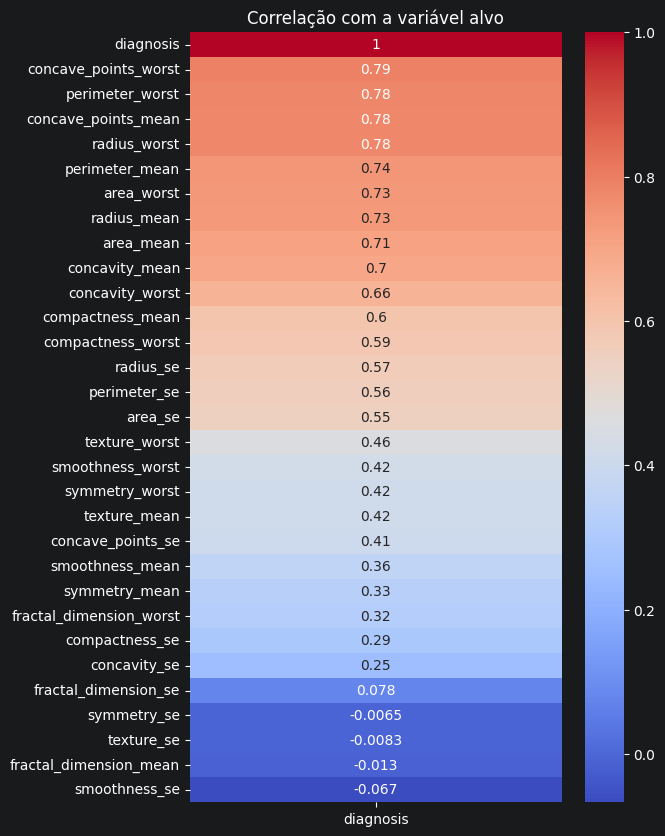

In [13]:
corr = df.corr()[['diagnosis']].sort_values(by='diagnosis', ascending=False)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlação com a variável alvo')
plt.show()

A análise de correlação com a variável alvo indica que atributos relacionados ao tamanho e à irregularidade do tumor apresentam maior associação com o diagnóstico. Em especial, variáveis como concave points, perimeter, radius e area, principalmente em suas versões `worst` e `mean`, apresentam correlações elevadas, sugerindo forte capacidade preditiva na distinção entre casos benignos e malignos. Esses resultados são coerentes do ponto de vista clínico, uma vez que tumores malignos tendem a apresentar maior tamanho e contornos mais irregulares, o que justifica a relevância dessas características no modelo.

Agora, fazendo uma análise descritiva mais explícita

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


In [15]:
# média dos dados agrupada por diagnóstico (0 benigno e 1 maligno).
df.groupby("diagnosis").mean().T

diagnosis,0,1
radius_mean,12.146524,17.462830
texture_mean,17.914762,21.604906
perimeter_mean,78.075406,115.365377
area_mean,462.790196,978.376415
smoothness_mean,0.092478,0.102898
compactness_mean,0.080085,0.145188
concavity_mean,0.046058,0.160775
concave_points_mean,0.025717,0.087990
symmetry_mean,0.174186,0.192909
fractal_dimension_mean,0.062867,0.062680


In [16]:
# mediana dos dados agrupada por diagnóstico (0 benigno e 1 maligno).
df.groupby("diagnosis").median().T

diagnosis,0,1
radius_mean,12.200000,17.325000
texture_mean,17.390000,21.460000
perimeter_mean,78.180000,114.200000
area_mean,458.400000,932.000000
smoothness_mean,0.090760,0.102200
compactness_mean,0.075290,0.132350
concavity_mean,0.037090,0.151350
concave_points_mean,0.023440,0.086280
symmetry_mean,0.171400,0.189900
fractal_dimension_mean,0.061540,0.061575


As estatísticas descritivas indicam diferenças relevantes entre os grupos benigno e maligno. Em média, os casos malignos apresentam maiores valores em variáveis associadas ao tamanho e ao contorno do tumor, como radius, perimeter, area, concavity e concave_points. Isso reforça os achados da análise de correlação e sugere que essas variáveis possuem potencial preditivo para a classificação.

Distribuição da variável alvo:

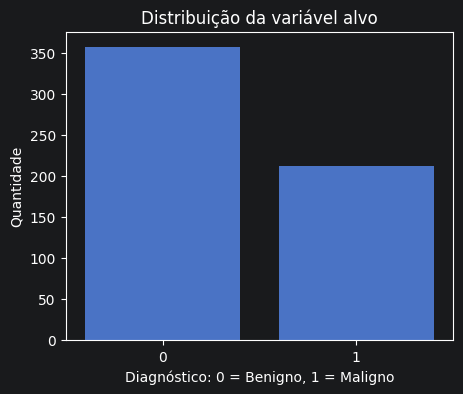

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="diagnosis")
plt.title("Distribuição da variável alvo")
plt.xlabel("Diagnóstico: 0 = Benigno, 1 = Maligno")
plt.ylabel("Quantidade")
plt.show()

Boxplots das principais variáveis

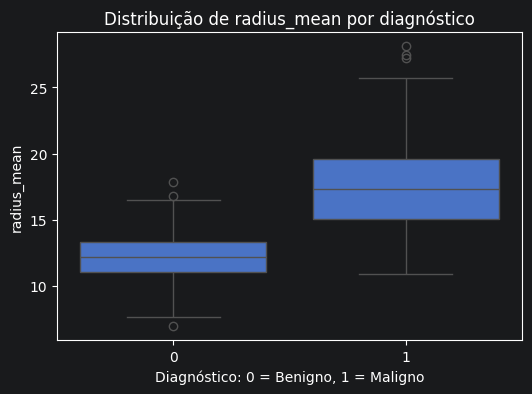

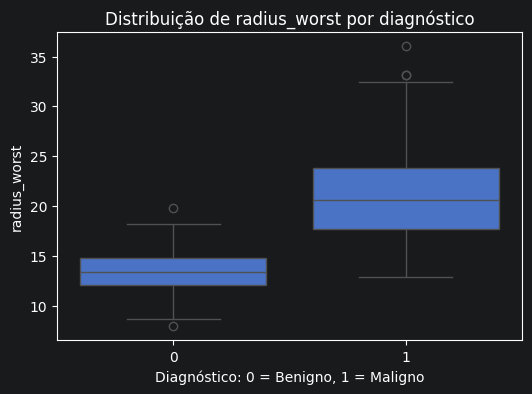

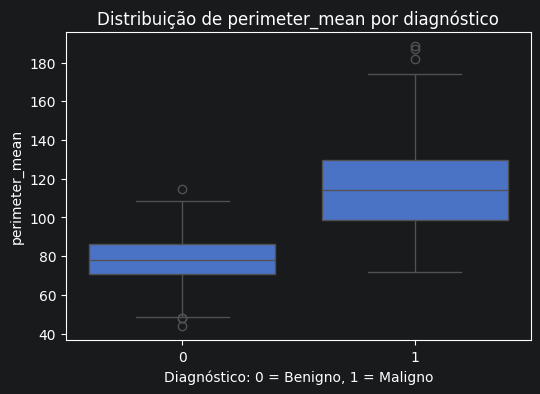

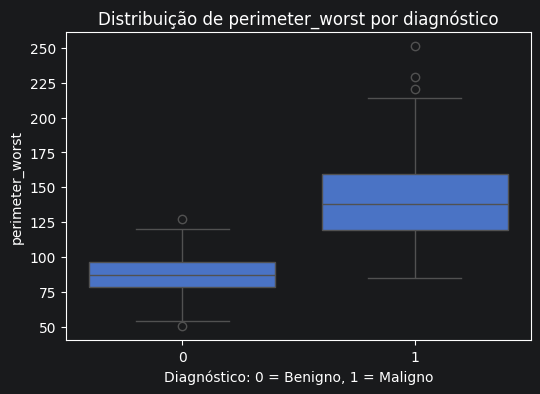

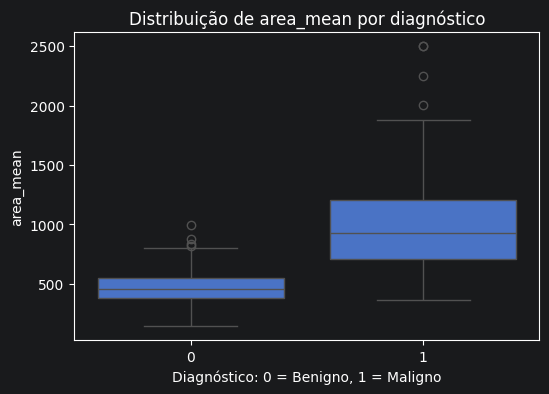

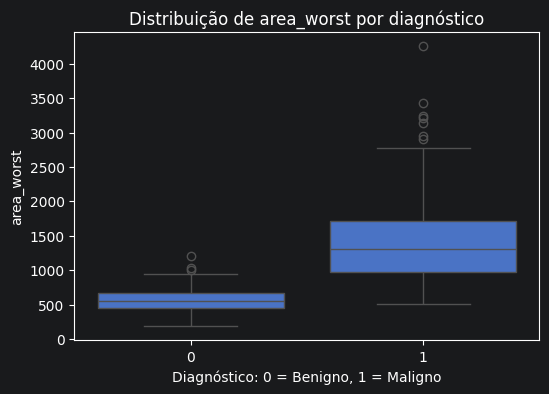

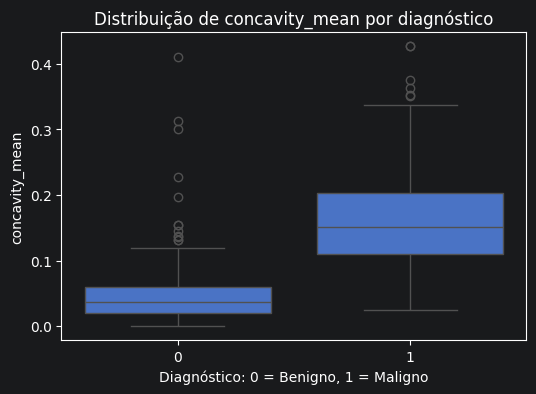

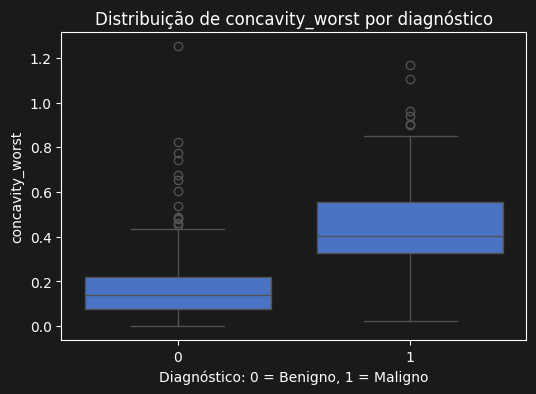

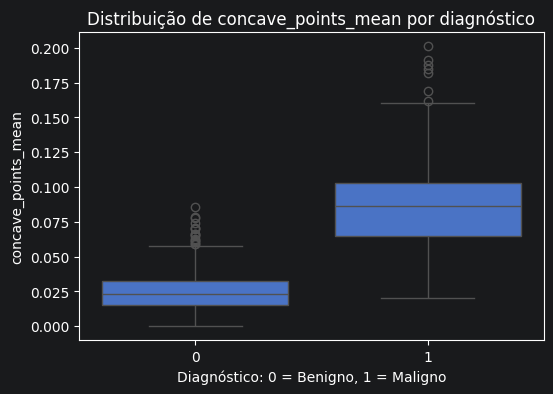

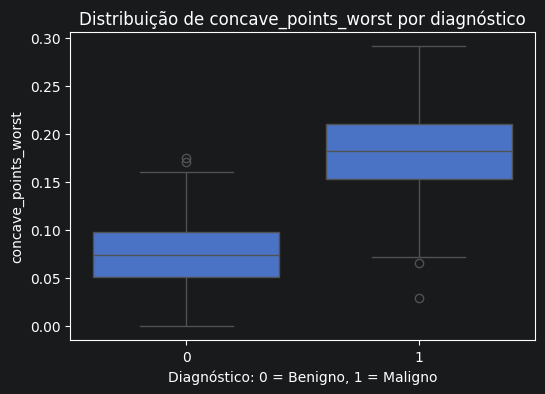

In [18]:
top_features = [
    "radius_mean", "radius_worst",
    "perimeter_mean", "perimeter_worst",
    "area_mean", "area_worst",
    "concavity_mean", "concavity_worst",
    "concave_points_mean", "concave_points_worst"
]

for col in top_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="diagnosis", y=col)
    plt.title(f"Distribuição de {col} por diagnóstico")
    plt.xlabel("Diagnóstico: 0 = Benigno, 1 = Maligno")
    plt.ylabel(col)
    plt.show()

Refazendo a análise acima, mas agora com a padronização das variáveis (apenas para visualização).

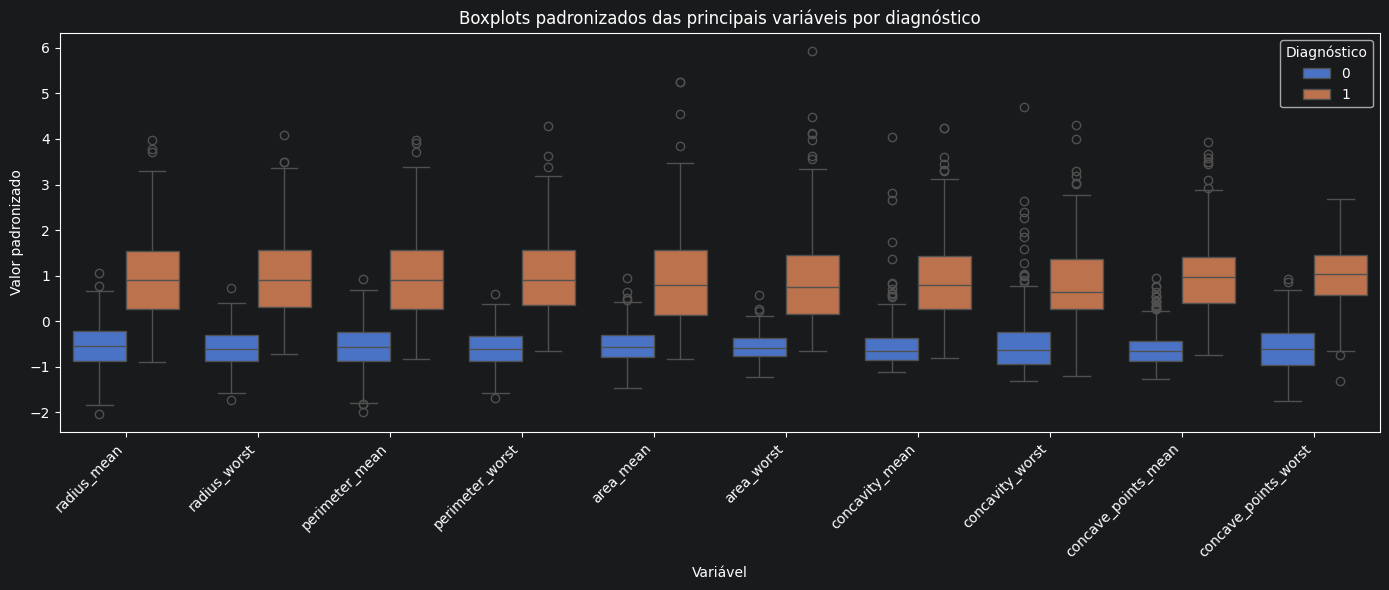

In [19]:
from sklearn.preprocessing import StandardScaler

df_scaled = df.copy()

scaler = StandardScaler()
df_scaled[top_features] = scaler.fit_transform(df_scaled[top_features])

df_long_scaled = df_scaled.melt(
    id_vars="diagnosis",
    value_vars=top_features,
    var_name="feature",
    value_name="valor_padronizado"
)

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_long_scaled,
    x="feature",
    y="valor_padronizado",
    hue="diagnosis"
)

plt.xticks(rotation=45, ha="right")
plt.title("Boxplots padronizados das principais variáveis por diagnóstico")
plt.xlabel("Variável")
plt.ylabel("Valor padronizado")
plt.legend(title="Diagnóstico")
plt.tight_layout()
plt.show()

Os boxplots padronizados permitem comparar variáveis em diferentes escalas. Observa-se que várias características dos grupos mean e worst apresentam separação visual entre diagnósticos benignos e malignos. As variáveis do grupo worst tendem a apresentar maior separação entre as classes, especialmente aquelas relacionadas ao tamanho e à irregularidade do tumor.

## 6. Treinamento do modelo: Separar treino e teste

Embora algumas variáveis apresentem alta correlação entre si, optou-se inicialmente por manter todas as variáveis preditoras válidas no treinamento dos modelos. Essa escolha evita a remoção prematura de informações potencialmente úteis. A relevância das variáveis será analisada posteriormente por meio de feature importance e/ou SHAP.

In [20]:
X = df.drop(columns="diagnosis")
y = df["diagnosis"]

In [21]:
X.shape, y.shape

((569, 30), (569,))

Foram separadas as variáveis preditoras, representadas por X, e a variável alvo, representada por y. Todas as variáveis numéricas válidas foram mantidas inicialmente no treinamento, evitando a remoção prematura de atributos potencialmente úteis.

Separação entre treino e teste — 80/20

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [23]:
X_train.shape, X_test.shape

((455, 30), (114, 30))

In [24]:
y_train.value_counts(normalize=True)

diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64

In [25]:
y_test.value_counts(normalize=True)

diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64

Os dados foram divididos em 80% para treino e 20% para teste. A divisão foi feita de forma estratificada, preservando proporções semelhantes de casos benignos e malignos nos dois conjuntos. O conjunto de teste será utilizado apenas na avaliação final do modelo escolhido.

Como foi adotada uma divisão principal em treino e teste, a etapa de validação dos modelos será realizada por validação cruzada dentro do conjunto de treino. Dessa forma, o conjunto de teste permanece isolado até a avaliação final.

## 7. Definição dos modelos

Foram selecionados três modelos de classificação: Regressão Logística, KNN e Random Forest.

A Regressão Logística foi utilizada como modelo de referência por ser simples, interpretável e adequada para problemas de classificação binária. O KNN foi incluído por ser um modelo baseado em proximidade entre observações, exigindo padronização das variáveis. A Random Forest foi utilizada por sua capacidade de capturar relações não lineares e fornecer medidas de importância das variáveis.

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

models = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42
        ))
    ])
}

In [27]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    cv_results.append({
        "modelo": name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "precision_mean": scores["test_precision"].mean(),
        "recall_mean": scores["test_recall"].mean(),
        "f1_mean": scores["test_f1"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.sort_values(by="recall_mean", ascending=False)

,modelo,accuracy_mean,precision_mean,recall_mean,f1_mean
0,Regressão Logística,0.971429,0.965022,0.958824,0.961623
2,Random Forest,0.962637,0.959246,0.941176,0.949490
1,KNN,0.964835,0.987500,0.917647,0.951042


A validação cruzada foi realizada apenas sobre o conjunto de treino. Essa estratégia permite comparar os modelos sem utilizar o conjunto de teste durante a escolha do melhor modelo.

A métrica de maior interesse neste problema é o recall da classe maligna, pois falsos negativos representam casos malignos classificados incorretamente como benignos. Em contexto médico, esse tipo de erro pode ter impacto mais grave do que um falso positivo.

## 8. Escolha do melhor modelo

A partir da validação cruzada realizada no conjunto de treino, a Regressão Logística apresentou o melhor desempenho geral entre os modelos avaliados. O modelo obteve accuracy média de 0,9714, precision média de 0,9650, recall médio de 0,9588 e F1-score médio de 0,9616.

Embora o KNN tenha apresentado a maior precision, seu recall foi inferior ao dos demais modelos. Em um problema de apoio ao diagnóstico de câncer de mama, o recall da classe maligna é uma métrica prioritária, pois falsos negativos representam casos malignos classificados incorretamente como benignos.

Dessa forma, a Regressão Logística foi selecionada como o melhor modelo para avaliação final no conjunto de teste, por apresentar o maior recall e o melhor equilíbrio geral entre as métricas.

Treinamento final com os 80% de treino

In [28]:
best_model_name = cv_results_df.sort_values(
    by="recall_mean",
    ascending=False
).iloc[0]["modelo"]

best_model_name

'Regressão Logística'

In [29]:
best_model = models[best_model_name]

Treinamento final com os 80% de treino. Após a comparação dos modelos por validação cruzada, o modelo selecionado foi treinado novamente utilizando todo o conjunto de treino.

In [30]:
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

## 9. Avaliação final no conjunto de teste

In [31]:
y_pred = best_model.predict(X_test)

In [32]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Benigno", "Maligno"]
))

              precision    recall  f1-score   support

     Benigno       0.97      0.99      0.98        72
     Maligno       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

test_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred)
}

test_metrics

{'accuracy': 0.9736842105263158,
 'precision': 0.975609756097561,
 'recall': 0.9523809523809523,
 'f1_score': 0.963855421686747}

### Avaliação final no conjunto de teste (Interpretação)

A avaliação final foi realizada no conjunto de teste, que não foi utilizado durante o treinamento nem durante a seleção do modelo. Essa separação é importante para verificar a capacidade de generalização do modelo em dados ainda não vistos.

Foram analisadas as métricas **accuracy**, **precision**, **recall** e **F1-score**. Embora a **accuracy** indique o percentual geral de acertos, ela não deve ser interpretada isoladamente neste problema. Como se trata de um contexto médico, a métrica mais relevante é o **recall da classe maligna**, pois mede a capacidade do modelo de identificar corretamente os casos malignos.

No conjunto de teste, havia:

- **72 casos benignos**
- **42 casos malignos**
- **114 registros no total**

A Regressão Logística apresentou os seguintes resultados para a classe maligna:

| Métrica | Resultado |
|---|---:|
| Accuracy | 0,9737 |
| Precision | 0,9756 |
| Recall | 0,9524 |
| F1-score | 0,9639 |

Os resultados são coerentes com o desempenho observado na validação cruzada. A Regressão Logística manteve alto desempenho no conjunto de teste, indicando boa capacidade de generalização para dados não utilizados durante o treinamento.

O **recall da classe maligna** foi de aproximadamente **95,24%**, o que significa que o modelo identificou corretamente cerca de **95% dos casos malignos** presentes no conjunto de teste. Considerando que havia 42 casos malignos, esse resultado indica que o modelo classificou corretamente aproximadamente **40 casos malignos** e deixou de identificar cerca de **2 casos malignos**, classificando-os incorretamente como benignos.

A **precision da classe maligna** foi de aproximadamente **97,56%**, indicando que, quando o modelo classificou um caso como maligno, a taxa de acerto foi elevada.

### Interpretação crítica

Apesar do desempenho geral elevado, os **falsos negativos** continuam sendo o principal ponto de atenção. Em um problema de apoio ao diagnóstico de câncer de mama, falsos negativos representam casos malignos classificados incorretamente como benignos, o que pode atrasar a investigação clínica e o tratamento adequado.

Portanto, embora o modelo apresente bom desempenho, ele não deve ser utilizado como ferramenta autônoma de diagnóstico. Seu uso mais adequado seria como instrumento de **apoio à triagem e à decisão médica**, auxiliando na priorização de casos e na análise inicial dos dados. A decisão final deve permanecer sob responsabilidade da equipe médica.

## Fazer Feature importance com Random Forest ? ???

## 10. Discussão crítica

Os resultados indicam que modelos de Machine Learning podem auxiliar na classificação inicial de tumores benignos e malignos a partir de dados estruturados. No entanto, o modelo não deve ser interpretado como uma ferramenta autônoma de diagnóstico.

Em uma aplicação real, o sistema poderia funcionar como apoio à triagem, destacando casos com maior probabilidade de malignidade para análise prioritária da equipe médica. Ainda assim, a decisão final deve permanecer sob responsabilidade do profissional de saúde.

Também existem limitações importantes. O dataset possui tamanho limitado e foi obtido em contexto controlado. Antes de qualquer uso prático, seria necessário validar o modelo com bases externas, dados de diferentes populações, dados coletados em condições reais e acompanhamento clínico adequado. Além disso, aspectos éticos, regulatórios, privacidade dos dados e impacto de falsos negativos precisam ser avaliados.

## 11. Conclusão

Neste trabalho, foi desenvolvido um fluxo de Machine Learning para classificação de tumores de mama como benignos ou malignos. O processo incluiu carregamento dos dados, limpeza, análise exploratória, análise de correlação, separação entre treino e teste, validação cruzada no conjunto de treino, treinamento de diferentes modelos de classificação e avaliação final no conjunto de teste.

A métrica de recall da classe maligna foi priorizada por sua relevância no contexto médico. Os resultados mostram que os modelos avaliados conseguem identificar padrões relevantes nos dados, principalmente em variáveis associadas ao tamanho e à irregularidade do tumor. Apesar do bom desempenho, o modelo deve ser entendido como ferramenta de apoio à decisão, e não como substituto da avaliação médica.